In [2]:
from matplotlib.pyplot import *
from pandas import *
from numpy import *

### Data

In [7]:
M = read_csv("data.csv")
M = M.values

### Calculations

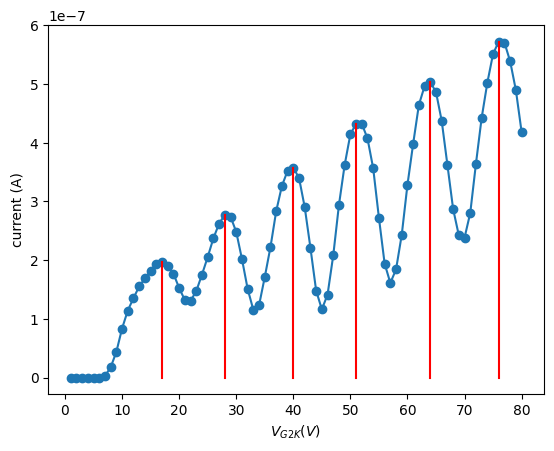

In [19]:
V = M[:,0]
I = M[:,1]
plot(V,I,'-o')
xlabel(r"$V_{G2K} (V)$ ")
ylabel("current (A)")

allowed_error = 1e-9

Peaks = [
    i for i in range(1,len(I)-1)
    if I[i] - I[i-1] >= allowed_error and I[i] - I[i+1] >= 0
    ]
MP = M[Peaks]

for X in MP:
    x,y = X
    plot([x,x],[0,y],"r")

In [23]:
V = [MP[i][0] for i in range(len(MP))]
Vd = [V[i] - V[i-1] for i in range(1,len(V))]
mu = sum(Vd)/len(Vd)
dev2 = [(x - mu)**2 for x in Vd]
Var = sum(dev2)/len(dev2)
sd = Var**0.5
print("Gaps (V) : ",Vd)
print("mean =",mu,"V")
print("standard deviation =",sd,"V")

Gaps (V) :  [11.0, 12.0, 11.0, 13.0, 12.0]
mean = 11.8 V
standard deviation = 0.7483314773547883 V


### Hand drawn graphs

#### All graphs

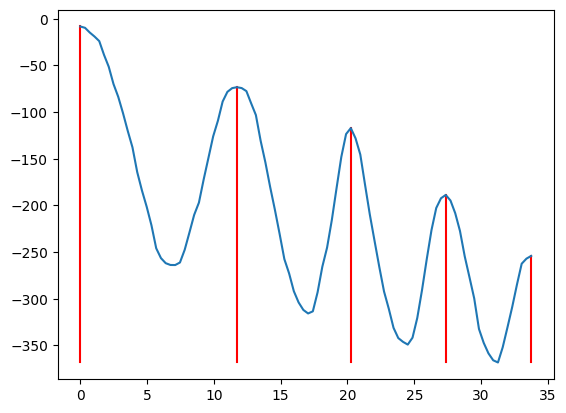

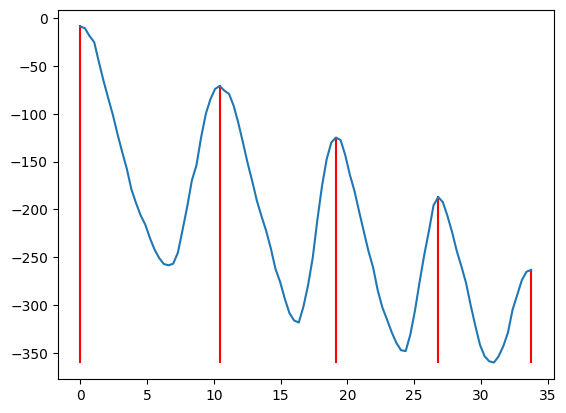

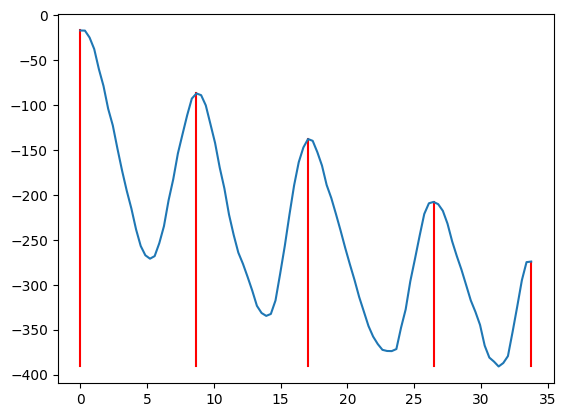

In [26]:
X0 = read_csv("Draw0.csv")
X0 = X0.values
X1 = read_csv("Draw1.csv")
X1 = X1.values
X2 = read_csv("Draw2.csv")
X2 = X2.values

XL = [X0,X1,X2]

for i,X in enumerate(XL):
    N = len(X)
    X = X[::N//100]
    X[:,1] = - X[:,1]
    XL[i] = X

for j,X in enumerate(XL):
    figure()
    V = X[:,0]
    I = X[:,1]
    N = len(V)
    Xn = [i for i in range(1,N-1) if 
          I[i-1] <= I[i] and I[i] >= I[i+1]
          ]
    Xd = X[Xn[0]:Xn[-1]+1]
    #Xn = X[Xn]
    X = Xd
    V = X[:,0]
    I = X[:,1]
    N = len(V)
    Vdiff = (2.1 + 2.2 + 2.2 + 2) * 4.012
    V = array([(i/N) * Vdiff for i in range(N)])
    minI = min(I)
    X[:,0] = V
    XL[j] = X
    DataFrame(X).to_csv(f"Draw{j}_clean.csv",index=False)
    for i in Xn:
        x,y = X[i-Xn[0]]
        plot([x,x],[minI,y],'r')
    plot(V,I)


Clearly, the 3rd graph is the best since it matches with the hand drawn one.

#### Draw2_clean.csv

Gaps (V) :  [11.0, 12.0, 11.0, 13.0, 12.0]
mean = 11.8 V
standard deviation = 0.7483314773547883 V


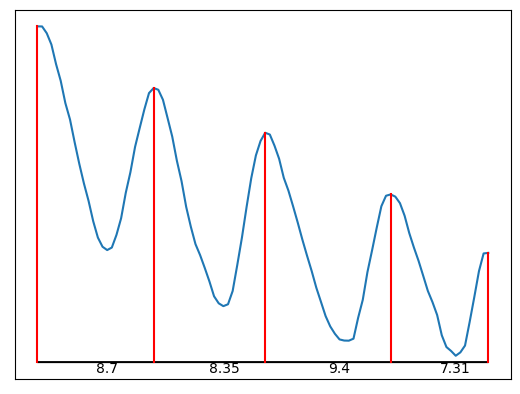

In [34]:
X = read_csv("Draw2_clean.csv")
X = X.values
V,I = X[:,0],X[:,1]
N = len(V)
peaks = [i for i in range(1,N-1) if I[i-1] <= I[i] and I[i+1] <= I[i]]
peaks = [0] + peaks + [N-1]
plot(V,I)
minI = min(I)
maxI = max(I)
low = minI - (maxI- minI)/50
lower = minI - (maxI - minI)/20
for j,i in enumerate(peaks):
    x,y = V[i],I[i]
    plot([x,x],[low,y],'r')
    if j+1 < len(peaks):
        x2 = V[peaks[j+1]]
        arrow(x,low,x2-x,0)
        arrow(x2,low,x-x2,0)
        text((x2+x)/2,lower ,str(round(abs(x2-x),2)))


V = [MP[i][0] for i in range(len(MP))]
Vd = [V[i] - V[i-1] for i in range(1,len(V))]
mu = sum(Vd)/len(Vd)
dev2 = [(x - mu)**2 for x in Vd]
Var = sum(dev2)/len(dev2)
sd = Var**0.5
xticks([])
yticks([])
print("Gaps (V) : ",Vd)
print("mean =",mu,"V")
print("standard deviation =",sd,"V")
    